# DriftGuard — Cumulative Drift Scoring Engine

This notebook converts hybrid security decisions into operational drift scores.

It generates:

- A 0–100 risk score for every field-level configuration change
- A separate confidence and uncertainty score
- Commit-level configuration-drift scores
- File-level decayed cumulative drift pressure
- Repository-level decayed cumulative drift pressure
- Current repository and file risk snapshots
- Operational review queues and hotspot reports

The scoring formula is fixed before final-test evaluation. Validation labels are
used only for reporting and are not inputs to the scoring function.

The cumulative score represents recent configuration-drift pressure. It should
not be interpreted as proof that a vulnerability remains active because the
dataset does not independently establish whether a later commit remediated each
earlier change.

In [1]:
import json
import math
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
)


print("=" * 72)
print("DRIFTGUARD — CUMULATIVE DRIFT SCORING ENGINE")
print("=" * 72)

current_directory = Path.cwd().resolve()

if current_directory.name.lower() == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

HYBRID_OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "hybrid_engine"
)

HYBRID_PREDICTIONS_PATH = (
    HYBRID_OUTPUT_DIR
    / "predictions"
    / "repository_validation_hybrid_predictions.csv.gz"
)

HYBRID_MANIFEST_PATH = (
    HYBRID_OUTPUT_DIR
    / "manifests"
    / "hybrid_engine_manifest.json"
)

SEALED_TEST_MANIFEST_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "repository_disjoint_evaluation"
    / "manifests"
    / "sealed_final_test_manifest.json"
)

OUTPUTS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "drift_scoring"
)

TABLES_DIR = OUTPUTS_DIR / "tables"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"
TIMELINES_DIR = OUTPUTS_DIR / "timelines"
FIGURES_DIR = OUTPUTS_DIR / "figures"
REVIEW_DIR = OUTPUTS_DIR / "manual_review"
MANIFESTS_DIR = OUTPUTS_DIR / "manifests"

CONFIGS_DIR = PROJECT_ROOT / "configs"

for directory in [
    OUTPUTS_DIR,
    TABLES_DIR,
    PREDICTIONS_DIR,
    TIMELINES_DIR,
    FIGURES_DIR,
    REVIEW_DIR,
    MANIFESTS_DIR,
    CONFIGS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

warnings.filterwarnings("default")

print("Project root       :", PROJECT_ROOT)
print("Hybrid predictions :", HYBRID_PREDICTIONS_PATH)
print("Output directory   :", OUTPUTS_DIR)

DRIFTGUARD — CUMULATIVE DRIFT SCORING ENGINE
Project root       : C:\Users\Lenovo\Desktop\DriftGuard
Hybrid predictions : C:\Users\Lenovo\Desktop\DriftGuard\outputs\hybrid_engine\predictions\repository_validation_hybrid_predictions.csv.gz
Output directory   : C:\Users\Lenovo\Desktop\DriftGuard\outputs\drift_scoring


In [2]:
DRIFT_SCORING_SETTINGS = {
    "class_order": [
        "benign",
        "low",
        "medium",
        "high",
        "critical",
    ],

    "severity_anchors": {
        "benign": 5.0,
        "low": 25.0,
        "medium": 50.0,
        "high": 75.0,
        "critical": 95.0,
    },

    "drift_bands": {
        "stable": {
            "minimum": 0.0,
            "maximum_exclusive": 15.0,
        },
        "watch": {
            "minimum": 15.0,
            "maximum_exclusive": 35.0,
        },
        "concerning": {
            "minimum": 35.0,
            "maximum_exclusive": 60.0,
        },
        "high": {
            "minimum": 60.0,
            "maximum_exclusive": 80.0,
        },
        "critical": {
            "minimum": 80.0,
            "maximum_exclusive": 100.000001,
        },
    },

    "band_to_label": {
        "stable": "benign",
        "watch": "low",
        "concerning": "medium",
        "high": "high",
        "critical": "critical",
    },

    "score_weights": {
        "decision_anchor": 0.55,
        "expected_probability_risk": 0.45,
    },

    "consensus_bonus": {
        "two_critical_votes": 8.0,
        "two_high_critical_votes": 5.0,
        "supported_single_critical_vote": 3.0,
    },

    "operation_bonus": {
        "security_relevant_removal": 4.0,
        "high_risk_addition": 2.0,
    },

    "supported_critical_probability": 0.45,

    "commit_score_weights": {
        "maximum_change_score": 0.50,
        "top_three_mean_score": 0.30,
        "risk_mass_score": 0.20,
    },

    "file_pressure_half_life_days": 90.0,

    "repository_pressure_half_life_days": 45.0,

    "event_exposure_weight": 0.65,

    "minimum_event_score_for_pressure": 10.0,

    "operational_review_queue_size": 1000,

    "hotspot_file_count": 100,

    "scoring_policy": (
        "Fixed before final-test evaluation. Validation labels are "
        "excluded from scoring inputs."
    ),
}

CLASS_ORDER = DRIFT_SCORING_SETTINGS[
    "class_order"
]

SEVERITY_ANCHORS = DRIFT_SCORING_SETTINGS[
    "severity_anchors"
]

BAND_TO_LABEL = DRIFT_SCORING_SETTINGS[
    "band_to_label"
]

scoring_settings_path = (
    CONFIGS_DIR
    / "drift_scoring_settings.json"
)

with scoring_settings_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        DRIFT_SCORING_SETTINGS,
        file,
        indent=2,
    )

print(
    json.dumps(
        DRIFT_SCORING_SETTINGS,
        indent=2,
    )
)

{
  "class_order": [
    "benign",
    "low",
    "medium",
    "high",
    "critical"
  ],
  "severity_anchors": {
    "benign": 5.0,
    "low": 25.0,
    "medium": 50.0,
    "high": 75.0,
    "critical": 95.0
  },
  "drift_bands": {
    "stable": {
      "minimum": 0.0,
      "maximum_exclusive": 15.0
    },
    "watch": {
      "minimum": 15.0,
      "maximum_exclusive": 35.0
    },
    "concerning": {
      "minimum": 35.0,
      "maximum_exclusive": 60.0
    },
    "high": {
      "minimum": 60.0,
      "maximum_exclusive": 80.0
    },
    "critical": {
      "minimum": 80.0,
      "maximum_exclusive": 100.000001
    }
  },
  "band_to_label": {
    "stable": "benign",
    "watch": "low",
    "concerning": "medium",
    "high": "high",
    "critical": "critical"
  },
  "score_weights": {
    "decision_anchor": 0.55,
    "expected_probability_risk": 0.45
  },
  "consensus_bonus": {
    "two_critical_votes": 8.0,
    "two_high_critical_votes": 5.0,
    "supported_single_critical_vote

In [3]:
required_artifacts = {
    "hybrid predictions":
        HYBRID_PREDICTIONS_PATH,

    "hybrid manifest":
        HYBRID_MANIFEST_PATH,

    "sealed final-test manifest":
        SEALED_TEST_MANIFEST_PATH,
}

for artifact_name, artifact_path in (
    required_artifacts.items()
):
    if not artifact_path.exists():
        raise FileNotFoundError(
            f"Missing {artifact_name}:\n"
            f"{artifact_path}"
        )

hybrid_data = pd.read_csv(
    HYBRID_PREDICTIONS_PATH,
    compression="gzip",
    low_memory=False,
)

with HYBRID_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    hybrid_manifest = json.load(file)

with SEALED_TEST_MANIFEST_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    sealed_test_manifest = json.load(file)

print(
    "Hybrid records:",
    f"{len(hybrid_data):,}",
)

print(
    "Production hybrid:",
    hybrid_manifest[
        "production_variant"
    ],
)

print(
    "Final test status:",
    sealed_test_manifest[
        "status"
    ],
)

print(
    "Final test SHA-256:",
    sealed_test_manifest[
        "sha256"
    ],
)

Hybrid records: 7,628
Production hybrid: safety_hybrid
Final test status: SEALED_NOT_LOADED
Final test SHA-256: cff0f85db740a195366fb81cbad26ba34859f40fe12bf8695b263d1cdedb9b67


In [4]:
IDENTIFIER_COLUMNS = [
    "diff_id",
    "repository",
    "commit_hash",
    "commit_author_date",
    "commit_message",
    "file_path",
    "configuration_type",
    "parser_mode",
    "operation",
    "field_path",
    "old_value",
    "new_value",
]

SCORING_INPUT_COLUMNS = [
    "operation",
    "safety_hybrid_prediction",
    "safety_hybrid_confidence",
    "rule_match_count",
    "rule_severity",
    "rule_severity_rank",
    "rule_confidence",
    "rule_override_applied",
    "model_consensus_escalation",
    "model_unique_prediction_count",
    "model_three_way_disagreement",
    "model_risk_spread",
    "high_critical_model_votes",
    "critical_model_votes",
    "ensemble_high_critical_probability",
    "requires_manual_review",
]

SCORING_INPUT_COLUMNS.extend(
    [
        f"safety_hybrid_score_{class_name}"
        for class_name in CLASS_ORDER
    ]
)

required_columns = (
    IDENTIFIER_COLUMNS
    + SCORING_INPUT_COLUMNS
    + [
        "evaluation_label",
        "deterministic_rule_ids",
        "decision_source",
        "decision_reason",
    ]
)

missing_columns = sorted(
    set(required_columns)
    - set(hybrid_data.columns)
)

if missing_columns:
    raise ValueError(
        "Hybrid predictions are missing columns:\n"
        + "\n".join(
            missing_columns
        )
    )

duplicate_columns = (
    hybrid_data.columns[
        hybrid_data.columns.duplicated()
    ]
    .tolist()
)

if duplicate_columns:
    raise ValueError(
        "Duplicate columns were found:\n"
        f"{duplicate_columns}"
    )

print("Required-column validation: PASSED")
print("Duplicate columns          :", duplicate_columns)

Required-column validation: PASSED
Duplicate columns          : []


In [5]:
FORBIDDEN_SCORING_COLUMNS = {
    "evaluation_label",
    "weak_label",
    "training_target",
    "primary_rule_id",
    "weak_label_confidence",
    "weak_label_reason",
    "label_source",
    "label_usage",
    "manual_label",
    "reviewer_notes",
}

scoring_label_overlap = (
    set(SCORING_INPUT_COLUMNS)
    & FORBIDDEN_SCORING_COLUMNS
)

print(
    "Scoring-input columns:",
    len(
        SCORING_INPUT_COLUMNS
    ),
)

print(
    "Forbidden-label overlap:",
    scoring_label_overlap,
)

if scoring_label_overlap:
    raise ValueError(
        "Evaluation or weak-label columns were included "
        "in the scoring inputs."
    )

print("Scoring-label isolation: PASSED")

Scoring-input columns: 21
Forbidden-label overlap: set()
Scoring-label isolation: PASSED


In [6]:
hybrid_data[
    "commit_timestamp"
] = pd.to_datetime(
    hybrid_data[
        "commit_author_date"
    ],
    errors="coerce",
    utc=True,
)

missing_timestamp_count = int(
    hybrid_data[
        "commit_timestamp"
    ].isna().sum()
)

print(
    "Missing timestamps before repair:",
    f"{missing_timestamp_count:,}",
)

if missing_timestamp_count > 0:
    hybrid_data = hybrid_data.sort_values(
        [
            "repository",
            "commit_hash",
            "diff_id",
        ]
    ).reset_index(drop=True)

    hybrid_data[
        "commit_timestamp"
    ] = (
        hybrid_data
        .groupby(
            "repository"
        )[
            "commit_timestamp"
        ]
        .transform(
            lambda series:
            series.ffill().bfill()
        )
    )

remaining_missing_timestamp_count = int(
    hybrid_data[
        "commit_timestamp"
    ].isna().sum()
)

if remaining_missing_timestamp_count > 0:
    fallback_start = pd.Timestamp(
        "1970-01-01",
        tz="UTC",
    )

    missing_mask = hybrid_data[
        "commit_timestamp"
    ].isna()

    fallback_offsets = np.arange(
        missing_mask.sum()
    )

    hybrid_data.loc[
        missing_mask,
        "commit_timestamp",
    ] = (
        fallback_start
        + pd.to_timedelta(
            fallback_offsets,
            unit="s",
        )
    )

for column in [
    "safety_hybrid_confidence",
    "rule_confidence",
    "rule_severity_rank",
    "model_unique_prediction_count",
    "model_risk_spread",
    "high_critical_model_votes",
    "critical_model_votes",
    "ensemble_high_critical_probability",
]:
    hybrid_data[column] = pd.to_numeric(
        hybrid_data[column],
        errors="coerce",
    ).fillna(0.0)

for class_name in CLASS_ORDER:
    probability_column = (
        f"safety_hybrid_score_{class_name}"
    )

    hybrid_data[
        probability_column
    ] = pd.to_numeric(
        hybrid_data[
            probability_column
        ],
        errors="coerce",
    ).fillna(0.0)

print(
    "Missing timestamps after repair:",
    int(
        hybrid_data[
            "commit_timestamp"
        ].isna().sum()
    ),
)

Missing timestamps before repair: 0
Missing timestamps after repair: 0


In [8]:
def extract_probability_matrix(
    dataframe,
):
    probability_columns = [
        f"safety_hybrid_score_{class_name}"
        for class_name in CLASS_ORDER
    ]

    probability_matrix = (
        dataframe[
            probability_columns
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    probability_matrix = np.clip(
        probability_matrix,
        0.0,
        None,
    )

    row_sums = probability_matrix.sum(
        axis=1
    )

    zero_sum_rows = (
        row_sums <= 0
    )

    if zero_sum_rows.any():
        probability_matrix[
            zero_sum_rows
        ] = (
            1.0
            / len(CLASS_ORDER)
        )

    probability_matrix = (
        probability_matrix
        / probability_matrix.sum(
            axis=1,
            keepdims=True,
        )
    )

    return probability_matrix


safety_probability_matrix = (
    extract_probability_matrix(
        hybrid_data
    )
)

print(
    "Probability matrix:",
    safety_probability_matrix.shape,
)

print(
    "Rows sum to one:",
    np.allclose(
        safety_probability_matrix.sum(
            axis=1
        ),
        1.0,
        atol=1e-8,
    ),
)

Probability matrix: (7628, 5)
Rows sum to one: True


In [9]:
def normalized_entropy(
    probability_matrix,
):
    clipped = np.clip(
        probability_matrix,
        1e-12,
        1.0,
    )

    entropy = -np.sum(
        clipped
        * np.log(
            clipped
        ),
        axis=1,
    )

    maximum_entropy = math.log(
        probability_matrix.shape[1]
    )

    return (
        entropy
        / maximum_entropy
    )


def assign_drift_band(
    score,
):
    score = float(
        np.clip(
            score,
            0.0,
            100.0,
        )
    )

    if score < 15.0:
        return "stable"

    if score < 35.0:
        return "watch"

    if score < 60.0:
        return "concerning"

    if score < 80.0:
        return "high"

    return "critical"


def normalized_operation(
    value,
):
    if pd.isna(value):
        return ""

    return str(
        value
    ).strip().lower()


def operation_is_removal(
    value,
):
    return normalized_operation(
        value
    ) in {
        "delete",
        "deleted",
        "remove",
        "removed",
    }


def operation_is_addition(
    value,
):
    return normalized_operation(
        value
    ) in {
        "add",
        "added",
        "insert",
        "inserted",
        "create",
        "created",
    }


print("Scoring helper functions loaded.")

Scoring helper functions loaded.


In [10]:
print("=" * 72)
print("CALCULATING FIELD-LEVEL DRIFT SCORES")
print("=" * 72)

severity_anchor_vector = np.array(
    [
        SEVERITY_ANCHORS[
            class_name
        ]
        for class_name in CLASS_ORDER
    ],
    dtype=np.float64,
)

expected_probability_risk = (
    safety_probability_matrix
    @ severity_anchor_vector
)

decision_anchor = (
    hybrid_data[
        "safety_hybrid_prediction"
    ]
    .map(
        SEVERITY_ANCHORS
    )
    .fillna(
        SEVERITY_ANCHORS[
            "benign"
        ]
    )
    .to_numpy(
        dtype=np.float64
    )
)

decision_weight = (
    DRIFT_SCORING_SETTINGS[
        "score_weights"
    ][
        "decision_anchor"
    ]
)

probability_weight = (
    DRIFT_SCORING_SETTINGS[
        "score_weights"
    ][
        "expected_probability_risk"
    ]
)

model_risk_component = (
    decision_weight
    * decision_anchor
    + probability_weight
    * expected_probability_risk
)

rule_anchor = (
    hybrid_data[
        "rule_severity"
    ]
    .map(
        SEVERITY_ANCHORS
    )
    .fillna(0.0)
    .to_numpy(
        dtype=np.float64
    )
)

rule_confidence = (
    hybrid_data[
        "rule_confidence"
    ]
    .clip(
        lower=0.0,
        upper=1.0,
    )
    .to_numpy(
        dtype=np.float64
    )
)

rule_match_mask = (
    hybrid_data[
        "rule_match_count"
    ]
    .fillna(0)
    .astype(float)
    .gt(0)
    .to_numpy()
)

rule_risk_floor = np.where(
    rule_match_mask,
    rule_anchor
    * (
        0.65
        + 0.35
        * rule_confidence
    ),
    0.0,
)

critical_votes = (
    hybrid_data[
        "critical_model_votes"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

high_critical_votes = (
    hybrid_data[
        "high_critical_model_votes"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

high_critical_probability = (
    hybrid_data[
        "ensemble_high_critical_probability"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

consensus_bonus = np.select(
    [
        critical_votes >= 2,

        high_critical_votes >= 2,

        (
            critical_votes >= 1
        )
        & (
            high_critical_probability
            >= DRIFT_SCORING_SETTINGS[
                "supported_critical_probability"
            ]
        ),
    ],
    [
        DRIFT_SCORING_SETTINGS[
            "consensus_bonus"
        ][
            "two_critical_votes"
        ],

        DRIFT_SCORING_SETTINGS[
            "consensus_bonus"
        ][
            "two_high_critical_votes"
        ],

        DRIFT_SCORING_SETTINGS[
            "consensus_bonus"
        ][
            "supported_single_critical_vote"
        ],
    ],
    default=0.0,
)

predicted_risk_rank = (
    hybrid_data[
        "safety_hybrid_prediction"
    ]
    .map(
        {
            class_name: index
            for index, class_name
            in enumerate(
                CLASS_ORDER
            )
        }
    )
    .fillna(0)
    .to_numpy(
        dtype=np.int64
    )
)

removal_mask = (
    hybrid_data[
        "operation"
    ]
    .apply(
        operation_is_removal
    )
    .to_numpy()
)

addition_mask = (
    hybrid_data[
        "operation"
    ]
    .apply(
        operation_is_addition
    )
    .to_numpy()
)

operation_bonus = np.zeros(
    len(
        hybrid_data
    ),
    dtype=np.float64,
)

operation_bonus[
    removal_mask
    & (
        predicted_risk_rank >= 2
    )
] += (
    DRIFT_SCORING_SETTINGS[
        "operation_bonus"
    ][
        "security_relevant_removal"
    ]
)

operation_bonus[
    addition_mask
    & (
        predicted_risk_rank >= 3
    )
] += (
    DRIFT_SCORING_SETTINGS[
        "operation_bonus"
    ][
        "high_risk_addition"
    ]
)

change_risk_score = np.maximum(
    model_risk_component,
    rule_risk_floor,
)

change_risk_score = np.clip(
    change_risk_score
    + consensus_bonus
    + operation_bonus,
    0.0,
    100.0,
)

hybrid_data[
    "expected_probability_risk"
] = expected_probability_risk

hybrid_data[
    "decision_anchor_score"
] = decision_anchor

hybrid_data[
    "model_risk_component"
] = model_risk_component

hybrid_data[
    "rule_risk_floor"
] = rule_risk_floor

hybrid_data[
    "consensus_score_bonus"
] = consensus_bonus

hybrid_data[
    "operation_score_bonus"
] = operation_bonus

hybrid_data[
    "change_risk_score"
] = change_risk_score

print(
    "Minimum change score:",
    f"{change_risk_score.min():.4f}",
)

print(
    "Maximum change score:",
    f"{change_risk_score.max():.4f}",
)

print(
    "Mean change score:",
    f"{change_risk_score.mean():.4f}",
)

CALCULATING FIELD-LEVEL DRIFT SCORES
Minimum change score: 5.6155
Maximum change score: 100.0000
Mean change score: 20.0668


In [11]:
entropy_values = normalized_entropy(
    safety_probability_matrix
)

uncertainty_score = (
    entropy_values
    * 100.0
)

model_unique_count = (
    hybrid_data[
        "model_unique_prediction_count"
    ]
    .clip(
        lower=1,
        upper=3,
    )
    .to_numpy(
        dtype=np.float64
    )
)

agreement_score = (
    1.0
    - (
        model_unique_count
        - 1.0
    )
    / 2.0
)

hybrid_confidence = (
    hybrid_data[
        "safety_hybrid_confidence"
    ]
    .clip(
        lower=0.0,
        upper=1.0,
    )
    .to_numpy(
        dtype=np.float64
    )
)

score_confidence = np.where(
    rule_match_mask,

    (
        0.50
        * hybrid_confidence
        + 0.25
        * agreement_score
        + 0.25
        * rule_confidence
    ),

    (
        0.70
        * hybrid_confidence
        + 0.30
        * agreement_score
    ),
)

score_confidence = np.clip(
    score_confidence
    * 100.0,
    0.0,
    100.0,
)

risk_spread = (
    hybrid_data[
        "model_risk_spread"
    ]
    .clip(
        lower=0,
        upper=4,
    )
    .to_numpy(
        dtype=np.float64
    )
)

rule_override = (
    hybrid_data[
        "rule_override_applied"
    ]
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

review_priority_score = (
    0.75
    * change_risk_score

    + 0.25
    * uncertainty_score

    + 5.0
    * risk_spread

    + np.where(
        rule_override,
        5.0,
        0.0,
    )
)

review_priority_score = np.clip(
    review_priority_score,
    0.0,
    100.0,
)

hybrid_data[
    "probability_entropy"
] = entropy_values

hybrid_data[
    "uncertainty_score"
] = uncertainty_score

hybrid_data[
    "model_agreement_score"
] = (
    agreement_score
    * 100.0
)

hybrid_data[
    "score_confidence"
] = score_confidence

hybrid_data[
    "operational_review_priority"
] = (
    review_priority_score
)

hybrid_data[
    "drift_band"
] = hybrid_data[
    "change_risk_score"
].apply(
    assign_drift_band
)

hybrid_data[
    "score_predicted_label"
] = hybrid_data[
    "drift_band"
].map(
    BAND_TO_LABEL
)

print(
    hybrid_data[
        "drift_band"
    ]
    .value_counts()
    .reindex(
        [
            "stable",
            "watch",
            "concerning",
            "high",
            "critical",
        ],
        fill_value=0,
    )
)

drift_band
stable        4079
watch         2883
concerning     209
high           349
critical       108
Name: count, dtype: int64


In [12]:
def build_score_explanation(
    row,
):
    explanation_parts = [
        (
            "Hybrid decision="
            f"{row['safety_hybrid_prediction']}"
        ),

        (
            "model component="
            f"{row['model_risk_component']:.2f}"
        ),

        (
            "expected probability risk="
            f"{row['expected_probability_risk']:.2f}"
        ),
    ]

    if float(
        row[
            "rule_risk_floor"
        ]
    ) > 0:
        explanation_parts.append(
            (
                "rule floor="
                f"{row['rule_risk_floor']:.2f}"
            )
        )

    if float(
        row[
            "consensus_score_bonus"
        ]
    ) > 0:
        explanation_parts.append(
            (
                "consensus bonus="
                f"{row['consensus_score_bonus']:.2f}"
            )
        )

    if float(
        row[
            "operation_score_bonus"
        ]
    ) > 0:
        explanation_parts.append(
            (
                "operation bonus="
                f"{row['operation_score_bonus']:.2f}"
            )
        )

    explanation_parts.extend(
        [
            (
                "final score="
                f"{row['change_risk_score']:.2f}"
            ),

            (
                "confidence="
                f"{row['score_confidence']:.2f}"
            ),

            (
                "band="
                f"{row['drift_band']}"
            ),
        ]
    )

    return "; ".join(
        explanation_parts
    )


hybrid_data[
    "score_explanation"
] = hybrid_data.apply(
    build_score_explanation,
    axis=1,
)

display(
    hybrid_data[
        [
            "repository",
            "file_path",
            "field_path",
            "safety_hybrid_prediction",
            "change_risk_score",
            "score_confidence",
            "uncertainty_score",
            "drift_band",
            "score_explanation",
        ]
    ].head(20)
)

,repository,file_path,field_path,safety_hybrid_prediction,change_risk_score,score_confidence,uncertainty_score,drift_band,score_explanation
0,kubernetes_examples,mysql-wordpress-pd/wordpress.yaml,$.desiredState.manifest.containers[0].volumeMo...,benign,7.468213,86.893082,37.515368,stable,Hybrid decision=benign; model component=7.47; ...
1,kubernetes_examples,spark/spark-worker-controller.json,$.spec.template.spec.containers[0].image,benign,7.391718,87.363186,36.869900,stable,Hybrid decision=benign; model component=7.39; ...
2,kubernetes_examples,cassandra/cassandra.yaml,$.spec.containers[0].env[2].value,high,69.440204,40.471214,70.344250,high,Hybrid decision=high; model component=65.44; e...
3,kubernetes_examples,mysql-wordpress-pd/mysql-service.yaml,$.port,low,24.991805,93.857633,22.994453,watch,Hybrid decision=low; model component=24.99; ex...
4,kubernetes_examples,cassandra/cassandra.yaml,$.spec.containers[0].env[2].name,benign,7.259454,87.226466,35.944839,stable,Hybrid decision=benign; model component=7.26; ...
5,kubernetes_examples,cassandra/image/cassandra.yaml,__line__.new[25],benign,12.752826,44.005182,63.683473,stable,Hybrid decision=benign; model component=12.75;...
6,kubernetes_examples,staging/volumes/rbd/rbd-with-secret.yaml,$.spec.volumes[0].rbd.monitors[2],low,26.597939,83.393996,49.976572,watch,Hybrid decision=low; model component=26.60; ex...
7,kubernetes_examples,limitrange/v1beta3/limit-range.json,__line__.new[24],low,26.650429,84.007441,48.860154,watch,Hybrid decision=low; model component=26.65; ex...
8,kubernetes_examples,nodesjs-mongodb/mongo-controller.yaml,$.spec.template.spec.volumes[0].gcePersistentD...,low,24.397172,65.540378,48.999280,watch,Hybrid decision=low; model component=24.40; ex...
9,kubernetes_examples,staging/oms/omsagent-daemonset.yaml,$.spec.template.spec.containers[0].securityCon...,high,74.517867,45.362639,73.331031,high,Hybrid decision=high; model component=65.52; e...


In [13]:
score_distribution = (
    hybrid_data[
        "drift_band"
    ]
    .value_counts()
    .reindex(
        [
            "stable",
            "watch",
            "concerning",
            "high",
            "critical",
        ],
        fill_value=0,
    )
    .rename_axis("drift_band")
    .reset_index(name="records")
)

score_distribution[
    "percentage"
] = (
    score_distribution[
        "records"
    ]
    / len(
        hybrid_data
    )
    * 100.0
)

display(
    score_distribution
)

repository_score_summary = (
    hybrid_data
    .groupby(
        "repository",
        dropna=False,
    )
    .agg(
        records=(
            "diff_id",
            "count",
        ),

        mean_change_score=(
            "change_risk_score",
            "mean",
        ),

        median_change_score=(
            "change_risk_score",
            "median",
        ),

        maximum_change_score=(
            "change_risk_score",
            "max",
        ),

        high_or_critical_changes=(
            "change_risk_score",
            lambda series:
            int(
                (
                    series >= 60.0
                ).sum()
            ),
        ),

        rule_matched_changes=(
            "rule_match_count",
            lambda series:
            int(
                (
                    series > 0
                ).sum()
            ),
        ),
    )
    .reset_index()
)

display(
    repository_score_summary
)

,drift_band,records,percentage
0,stable,4079,53.474043
1,watch,2883,37.794966
2,concerning,209,2.739906
3,high,349,4.575249
4,critical,108,1.415836


,repository,records,mean_change_score,median_change_score,maximum_change_score,high_or_critical_changes,rule_matched_changes
0,kubernetes_examples,7628,20.066831,11.450578,100.0,457,252


In [14]:
def aggregate_event_scores(
    score_values,
):
    values = np.asarray(
        score_values,
        dtype=np.float64,
    )

    if len(values) == 0:
        return {
            "maximum_score": 0.0,
            "top_three_mean_score": 0.0,
            "risk_mass_score": 0.0,
            "event_score": 0.0,
        }

    descending = np.sort(
        values
    )[::-1]

    maximum_score = float(
        descending[0]
    )

    top_three_mean_score = float(
        descending[
            :min(
                3,
                len(descending),
            )
        ].mean()
    )

    risk_mass = float(
        np.sum(
            values
            / 100.0
        )
    )

    risk_mass_score = float(
        100.0
        * (
            1.0
            - np.exp(
                -risk_mass
                / 4.0
            )
        )
    )

    weights = (
        DRIFT_SCORING_SETTINGS[
            "commit_score_weights"
        ]
    )

    event_score = (
        weights[
            "maximum_change_score"
        ]
        * maximum_score

        + weights[
            "top_three_mean_score"
        ]
        * top_three_mean_score

        + weights[
            "risk_mass_score"
        ]
        * risk_mass_score
    )

    event_score = float(
        np.clip(
            event_score,
            0.0,
            100.0,
        )
    )

    return {
        "maximum_score":
            maximum_score,

        "top_three_mean_score":
            top_three_mean_score,

        "risk_mass_score":
            risk_mass_score,

        "event_score":
            event_score,
    }


print("Event aggregation helper loaded.")

Event aggregation helper loaded.


In [15]:
print("=" * 72)
print("BUILDING COMMIT-LEVEL DRIFT SCORES")
print("=" * 72)

commit_records = []

commit_group_columns = [
    "repository",
    "commit_hash",
]

for (
    repository,
    commit_hash,
), group in hybrid_data.groupby(
    commit_group_columns,
    sort=False,
    dropna=False,
):
    aggregate_scores = (
        aggregate_event_scores(
            group[
                "change_risk_score"
            ].to_numpy()
        )
    )

    score_weights = np.maximum(
        group[
            "change_risk_score"
        ].to_numpy(
            dtype=np.float64
        ),
        1.0,
    )

    weighted_confidence = float(
        np.average(
            group[
                "score_confidence"
            ].to_numpy(
                dtype=np.float64
            ),
            weights=score_weights,
        )
    )

    commit_records.append(
        {
            "repository":
                repository,

            "commit_hash":
                commit_hash,

            "commit_timestamp":
                group[
                    "commit_timestamp"
                ].min(),

            "commit_message":
                group[
                    "commit_message"
                ].iloc[0],

            "changed_fields":
                int(
                    len(group)
                ),

            "changed_files":
                int(
                    group[
                        "file_path"
                    ].nunique()
                ),

            "risky_change_count":
                int(
                    (
                        group[
                            "change_risk_score"
                        ]
                        >= 35.0
                    ).sum()
                ),

            "high_change_count":
                int(
                    (
                        group[
                            "change_risk_score"
                        ]
                        >= 60.0
                    ).sum()
                ),

            "critical_change_count":
                int(
                    (
                        group[
                            "change_risk_score"
                        ]
                        >= 80.0
                    ).sum()
                ),

            "rule_matched_change_count":
                int(
                    (
                        group[
                            "rule_match_count"
                        ]
                        > 0
                    ).sum()
                ),

            "manual_review_change_count":
                int(
                    group[
                        "requires_manual_review"
                    ]
                    .fillna(False)
                    .astype(bool)
                    .sum()
                ),

            "maximum_change_score":
                aggregate_scores[
                    "maximum_score"
                ],

            "top_three_mean_score":
                aggregate_scores[
                    "top_three_mean_score"
                ],

            "risk_mass_score":
                aggregate_scores[
                    "risk_mass_score"
                ],

            "commit_drift_score":
                aggregate_scores[
                    "event_score"
                ],

            "commit_score_confidence":
                weighted_confidence,

            "maximum_review_priority":
                float(
                    group[
                        "operational_review_priority"
                    ].max()
                ),
        }
    )

commit_scores = pd.DataFrame(
    commit_records
)

commit_scores[
    "commit_drift_band"
] = commit_scores[
    "commit_drift_score"
].apply(
    assign_drift_band
)

commit_scores = commit_scores.sort_values(
    [
        "repository",
        "commit_timestamp",
        "commit_hash",
    ]
).reset_index(drop=True)

print(
    "Commit score records:",
    f"{len(commit_scores):,}",
)

display(
    commit_scores
    .sort_values(
        "commit_drift_score",
        ascending=False,
    )
    .head(20)
)

BUILDING COMMIT-LEVEL DRIFT SCORES
Commit score records: 534


,repository,commit_hash,commit_timestamp,commit_message,changed_fields,changed_files,risky_change_count,high_change_count,critical_change_count,rule_matched_change_count,manual_review_change_count,maximum_change_score,top_three_mean_score,risk_mass_score,commit_drift_score,commit_score_confidence,maximum_review_priority,commit_drift_band
525,kubernetes_examples,4eebb8c87a66cdd723bc599c534019aa678e4408,2025-05-27 15:57:32+00:00,Drop example already covered in official docs\...,74,4,14,11,6,9,14,100.000000,100.000000,99.448207,99.889641,64.913353,100.000000,critical
216,kubernetes_examples,1219478f1b08a44fcc99f0ca4dfd8c808b019382,2015-07-14 16:32:07+00:00,move user docs to their new home,207,43,40,11,3,32,34,98.667500,98.667500,99.998656,98.933731,69.973063,97.330547,critical
341,kubernetes_examples,afb2eff237a46abde1fa4c1278b63980eab26249,2016-07-16 19:08:11+00:00,- updates to docker\n- updating java to 3.7\n-...,86,5,10,8,6,1,15,97.176736,93.827595,99.598842,96.656415,64.220225,100.000000,critical
529,kubernetes_examples,289fdef1b9098439909fd22735a886f5e44d8229,2025-08-25 17:17:44+00:00,hpa recipe for ai inference using gpu custom m...,144,9,8,8,5,1,7,99.459917,88.999223,99.958777,96.421481,75.042914,100.000000,critical
64,kubernetes_examples,07bd1473751daf665b42445f98cbff4341b3c49e,2015-02-19 12:38:22+00:00,new changes,41,6,3,3,3,3,5,98.667500,98.667500,86.769605,96.287921,75.698682,100.000000,critical
415,kubernetes_examples,48540305e652ab439fe0a44decaab1eae81eb8fe,2017-03-20 17:53:06+00:00,update iSCSI README with CHAP instruction\n\nS...,17,2,10,10,9,0,10,96.954683,92.491365,92.159395,94.656630,59.167940,100.000000,critical
57,kubernetes_examples,6ef691cf3aa2dca002e9c20329b408ec625d22fc,2015-02-04 04:35:13+00:00,Add an example for running rethinkdb cluster o...,49,5,3,3,2,3,3,96.335000,89.540000,92.734741,93.576448,76.083349,100.000000,critical
139,kubernetes_examples,de6b41f95853d7d2f773fde993e6cbccc4e5da4c,2015-05-05 14:23:47+00:00,Fix OpenShift example,31,3,3,3,2,2,4,100.000000,88.392694,85.225887,93.562985,76.116694,100.000000,critical
250,kubernetes_examples,e97070d8f1bb83a924ba73d4c94240e1d47c3bf6,2015-09-28 12:03:06+00:00,Update cephfs example according to config best...,29,4,3,3,2,2,3,98.667500,89.963698,83.335822,92.990024,69.164377,100.000000,critical
471,kubernetes_examples,e4cc298ab61807a39086ef91374d0b6d87a2a9f4,2018-03-14 18:26:26+00:00,Import kubernetes updates (#210)\n\n* Admin Ca...,118,31,15,8,1,4,79,96.667500,81.325737,99.863099,92.704091,64.683131,96.564637,critical


In [16]:
file_event_records = []

for (
    repository,
    file_path,
    commit_hash,
), group in hybrid_data.groupby(
    [
        "repository",
        "file_path",
        "commit_hash",
    ],
    sort=False,
    dropna=False,
):
    aggregate_scores = (
        aggregate_event_scores(
            group[
                "change_risk_score"
            ].to_numpy()
        )
    )

    file_event_records.append(
        {
            "repository":
                repository,

            "file_path":
                file_path,

            "commit_hash":
                commit_hash,

            "commit_timestamp":
                group[
                    "commit_timestamp"
                ].min(),

            "field_change_count":
                int(
                    len(group)
                ),

            "high_or_critical_changes":
                int(
                    (
                        group[
                            "change_risk_score"
                        ]
                        >= 60.0
                    ).sum()
                ),

            "rule_matched_changes":
                int(
                    (
                        group[
                            "rule_match_count"
                        ]
                        > 0
                    ).sum()
                ),

            "maximum_change_score":
                aggregate_scores[
                    "maximum_score"
                ],

            "file_event_drift_score":
                aggregate_scores[
                    "event_score"
                ],
        }
    )

file_event_scores = pd.DataFrame(
    file_event_records
)

file_event_scores = (
    file_event_scores
    .sort_values(
        [
            "repository",
            "file_path",
            "commit_timestamp",
            "commit_hash",
        ]
    )
    .reset_index(drop=True)
)

print(
    "File-commit events:",
    f"{len(file_event_scores):,}",
)

File-commit events: 1,449


In [17]:
def calculate_decayed_pressure(
    dataframe,
    group_columns,
    timestamp_column,
    event_score_column,
    half_life_days,
):
    output_records = []

    minimum_event_score = (
        DRIFT_SCORING_SETTINGS[
            "minimum_event_score_for_pressure"
        ]
    )

    event_exposure_weight = (
        DRIFT_SCORING_SETTINGS[
            "event_exposure_weight"
        ]
    )

    grouped = dataframe.groupby(
        group_columns,
        sort=False,
        dropna=False,
    )

    for group_key, group in grouped:
        group = group.sort_values(
            [
                timestamp_column,
                "commit_hash",
            ]
        )

        previous_pressure = 0.0
        previous_timestamp = None

        for _, row in group.iterrows():
            current_timestamp = row[
                timestamp_column
            ]

            if previous_timestamp is None:
                elapsed_days = 0.0
            else:
                elapsed_days = max(
                    (
                        current_timestamp
                        - previous_timestamp
                    ).total_seconds()
                    / 86400.0,
                    0.0,
                )

            decay_factor = float(
                0.5
                ** (
                    elapsed_days
                    / half_life_days
                )
            )

            decayed_previous_pressure = (
                previous_pressure
                * decay_factor
            )

            event_score = float(
                row[
                    event_score_column
                ]
            )

            normalized_event_exposure = (
                max(
                    event_score
                    - minimum_event_score,
                    0.0,
                )
                / (
                    100.0
                    - minimum_event_score
                )
            )

            event_exposure = float(
                np.clip(
                    normalized_event_exposure
                    * event_exposure_weight,
                    0.0,
                    1.0,
                )
            )

            current_pressure = (
                100.0
                * (
                    1.0
                    - (
                        1.0
                        - decayed_previous_pressure
                        / 100.0
                    )
                    * (
                        1.0
                        - event_exposure
                    )
                )
            )

            current_pressure = float(
                np.clip(
                    current_pressure,
                    0.0,
                    100.0,
                )
            )

            output_row = row.to_dict()

            output_row.update(
                {
                    "elapsed_days":
                        elapsed_days,

                    "decay_factor":
                        decay_factor,

                    "pressure_before_event":
                        decayed_previous_pressure,

                    "normalized_event_exposure":
                        normalized_event_exposure,

                    "event_exposure":
                        event_exposure,

                    "cumulative_drift_pressure":
                        current_pressure,

                    "cumulative_drift_band":
                        assign_drift_band(
                            current_pressure
                        ),
                }
            )

            output_records.append(
                output_row
            )

            previous_pressure = (
                current_pressure
            )

            previous_timestamp = (
                current_timestamp
            )

    return pd.DataFrame(
        output_records
    )


print("Decayed-pressure function loaded.")

Decayed-pressure function loaded.


In [18]:
print("=" * 72)
print("CALCULATING FILE-LEVEL CUMULATIVE PRESSURE")
print("=" * 72)

file_drift_timeline = (
    calculate_decayed_pressure(
        dataframe=file_event_scores,

        group_columns=[
            "repository",
            "file_path",
        ],

        timestamp_column=(
            "commit_timestamp"
        ),

        event_score_column=(
            "file_event_drift_score"
        ),

        half_life_days=(
            DRIFT_SCORING_SETTINGS[
                "file_pressure_half_life_days"
            ]
        ),
    )
)

file_current_snapshot = (
    file_drift_timeline
    .sort_values(
        [
            "repository",
            "file_path",
            "commit_timestamp",
        ]
    )
    .groupby(
        [
            "repository",
            "file_path",
        ],
        as_index=False,
        dropna=False,
    )
    .tail(1)
    .reset_index(drop=True)
)

file_current_snapshot = (
    file_current_snapshot
    .sort_values(
        "cumulative_drift_pressure",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    "File timeline records:",
    f"{len(file_drift_timeline):,}",
)

print(
    "Current file snapshots:",
    f"{len(file_current_snapshot):,}",
)

display(
    file_current_snapshot[
        [
            "repository",
            "file_path",
            "commit_timestamp",
            "file_event_drift_score",
            "cumulative_drift_pressure",
            "cumulative_drift_band",
        ]
    ].head(30)
)

CALCULATING FILE-LEVEL CUMULATIVE PRESSURE
File timeline records: 1,449
Current file snapshots: 609


,repository,file_path,commit_timestamp,file_event_drift_score,cumulative_drift_pressure,cumulative_drift_band
0,kubernetes_examples,mysql-wordpress-pd/mysql-deployment.yaml,2025-05-27 15:57:32+00:00,98.050930,74.006219,high
1,kubernetes_examples,scheduler/scheduler-policy-config-with-extende...,2018-04-09 21:46:53+00:00,81.306044,66.869046,high
2,kubernetes_examples,monitoring/influx-grafana-pod.json,2015-01-05 18:22:04+00:00,69.144572,65.673298,high
3,kubernetes_examples,mysql-wordpress-pd/v1beta3/wordpress.yaml,2015-05-06 22:14:16+00:00,64.077139,65.649314,high
4,kubernetes_examples,openshift-origin/origin-kubeconfig.yaml,2015-05-05 14:23:47+00:00,84.493139,65.397286,high
5,kubernetes_examples,multi-pod.yaml,2015-07-14 16:32:07+00:00,74.530227,64.725815,high
6,kubernetes_examples,staging/javaweb-tomcat-sidecar/javaweb.yaml,2018-09-19 15:38:42+00:00,21.666752,64.103588,high
7,kubernetes_examples,resourcequota/v1beta3/resource-quota.json,2015-05-07 20:54:24+00:00,83.104127,63.860396,high
8,kubernetes_examples,AI/vllm-deployment/hpa/prometheus-adapter.yaml,2025-08-25 17:17:44+00:00,96.331095,62.350235,high
9,kubernetes_examples,experimental/persistent-volume-provisioning/qu...,2016-09-16 11:25:25+00:00,69.276848,60.580206,high


In [19]:
print("=" * 72)
print("CALCULATING REPOSITORY-LEVEL CUMULATIVE PRESSURE")
print("=" * 72)

repository_drift_timeline = (
    calculate_decayed_pressure(
        dataframe=commit_scores,

        group_columns=[
            "repository",
        ],

        timestamp_column=(
            "commit_timestamp"
        ),

        event_score_column=(
            "commit_drift_score"
        ),

        half_life_days=(
            DRIFT_SCORING_SETTINGS[
                "repository_pressure_half_life_days"
            ]
        ),
    )
)

repository_current_snapshot = (
    repository_drift_timeline
    .sort_values(
        [
            "repository",
            "commit_timestamp",
        ]
    )
    .groupby(
        "repository",
        as_index=False,
        dropna=False,
    )
    .tail(1)
    .reset_index(drop=True)
)

repository_current_snapshot = (
    repository_current_snapshot
    .sort_values(
        "cumulative_drift_pressure",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    repository_current_snapshot[
        [
            "repository",
            "commit_timestamp",
            "commit_drift_score",
            "cumulative_drift_pressure",
            "cumulative_drift_band",
            "high_change_count",
            "critical_change_count",
        ]
    ]
)

CALCULATING REPOSITORY-LEVEL CUMULATIVE PRESSURE


,repository,commit_timestamp,commit_drift_score,cumulative_drift_pressure,cumulative_drift_band,high_change_count,critical_change_count
0,kubernetes_examples,2026-02-28 09:59:04+00:00,39.730213,42.399045,concerning,0,0


In [20]:
file_hotspots = (
    file_current_snapshot
    .head(
        DRIFT_SCORING_SETTINGS[
            "hotspot_file_count"
        ]
    )
    .copy()
)

commit_hotspots = (
    commit_scores
    .sort_values(
        [
            "commit_drift_score",
            "maximum_review_priority",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(100)
    .copy()
)

field_hotspots = (
    hybrid_data
    .sort_values(
        [
            "change_risk_score",
            "operational_review_priority",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(250)
    .copy()
)

print(
    "File hotspots:",
    len(
        file_hotspots
    ),
)

print(
    "Commit hotspots:",
    len(
        commit_hotspots
    ),
)

print(
    "Field hotspots:",
    len(
        field_hotspots
    ),
)

File hotspots: 100
Commit hotspots: 100
Field hotspots: 250


In [21]:
operational_review_mask = (
    hybrid_data[
        "requires_manual_review"
    ]
    .fillna(False)
    .astype(bool)

    | (
        hybrid_data[
            "change_risk_score"
        ]
        >= 60.0
    )

    | (
        hybrid_data[
            "operational_review_priority"
        ]
        >= 65.0
    )
)

operational_review_queue = (
    hybrid_data[
        operational_review_mask
    ]
    .sort_values(
        [
            "operational_review_priority",
            "change_risk_score",
            "uncertainty_score",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .head(
        DRIFT_SCORING_SETTINGS[
            "operational_review_queue_size"
        ]
    )
    .copy()
)

operational_review_queue[
    "review_status"
] = "pending"

operational_review_queue[
    "reviewer_decision"
] = ""

operational_review_queue[
    "reviewer_notes"
] = ""

print(
    "Operational review candidates:",
    f"{operational_review_mask.sum():,}",
)

print(
    "Saved queue size:",
    f"{len(operational_review_queue):,}",
)

display(
    operational_review_queue[
        [
            "repository",
            "commit_hash",
            "file_path",
            "field_path",
            "old_value",
            "new_value",
            "safety_hybrid_prediction",
            "change_risk_score",
            "score_confidence",
            "uncertainty_score",
            "operational_review_priority",
            "deterministic_rule_ids",
        ]
    ].head(30)
)

Operational review candidates: 1,170
Saved queue size: 1,000


,repository,commit_hash,file_path,field_path,old_value,new_value,safety_hybrid_prediction,change_risk_score,score_confidence,uncertainty_score,operational_review_priority,deterministic_rule_ids
6414,kubernetes_examples,8be6732dcbc613aef0d1628eb9a226786df37f7e,scheduler-policy-config-with-extender.json,$.extender.enableHttps,false,NaN,critical,100.000000,61.195108,68.924708,100.0,TLS_DISABLED
3742,kubernetes_examples,4eebb8c87a66cdd723bc599c534019aa678e4408,mysql-wordpress-pd/mysql-deployment.yaml,$.documents[2].spec.template.spec.containers[0...,password,NaN,critical,100.000000,68.801130,68.075299,100.0,AUTH_REMOVED
6085,kubernetes_examples,4eebb8c87a66cdd723bc599c534019aa678e4408,mysql-wordpress-pd/mysql-deployment.yaml,$.documents[2].spec.template.spec.containers[0...,password,NaN,critical,100.000000,68.896554,67.836615,100.0,AUTH_REMOVED
6518,kubernetes_examples,4eebb8c87a66cdd723bc599c534019aa678e4408,mysql-wordpress-pd/wordpress-deployment.yaml,$.documents[2].spec.template.spec.containers[0...,password,NaN,critical,100.000000,68.980692,67.591376,100.0,AUTH_REMOVED
393,kubernetes_examples,37631d5f2f444b72bfb9f19efa98a5a762be842e,scheduler/scheduler-policy-config-with-extende...,$.extenders[0].enableHttps,false,NaN,critical,100.000000,68.926782,63.581845,100.0,TLS_DISABLED
992,kubernetes_examples,de6b41f95853d7d2f773fde993e6cbccc4e5da4c,openshift-origin/origin-kubeconfig.yaml,$.users[0].user.auth-path,/etc/secret-volume/kube-auth-path,NaN,critical,100.000000,70.152404,59.399282,100.0,AUTH_REMOVED
7347,kubernetes_examples,07bd1473751daf665b42445f98cbff4341b3c49e,guestbook/guestbook_ns/redis-slave-controller....,$.spec.template.spec.dnsPolicy,ClusterFirst,NaN,critical,98.667500,53.945319,81.406729,100.0,AUTH_REMOVED
1370,kubernetes_examples,4eebb8c87a66cdd723bc599c534019aa678e4408,mysql-wordpress-pd/mysql-deployment.yaml,$.documents[2].spec.template.spec.containers[0...,mysql-pass,NaN,critical,98.667500,53.717697,81.342472,100.0,AUTH_REMOVED
2122,kubernetes_examples,4eebb8c87a66cdd723bc599c534019aa678e4408,mysql-wordpress-pd/wordpress-deployment.yaml,$.documents[2].spec.template.spec.containers[0...,mysql-pass,NaN,critical,98.667500,53.827562,81.199942,100.0,AUTH_REMOVED
428,kubernetes_examples,4eebb8c87a66cdd723bc599c534019aa678e4408,mysql-wordpress-pd/mysql-deployment.yaml,$.documents[2].spec.template.spec.containers[0...,mysql-pass,NaN,critical,98.667500,54.852158,80.706972,100.0,AUTH_REMOVED


In [22]:
labeled_mask = (
    hybrid_data[
        "evaluation_label"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(
        CLASS_ORDER
    )
)

true_labels = (
    hybrid_data.loc[
        labeled_mask,
        "evaluation_label",
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .to_numpy()
)

score_predicted_labels = (
    hybrid_data.loc[
        labeled_mask,
        "score_predicted_label",
    ]
    .astype(str)
    .to_numpy()
)

labeled_scores = (
    hybrid_data.loc[
        labeled_mask,
        "change_risk_score",
    ]
    .to_numpy(
        dtype=np.float64
    )
)

true_anchor_scores = np.array(
    [
        SEVERITY_ANCHORS[
            label
        ]
        for label in true_labels
    ],
    dtype=np.float64,
)

true_ranks = pd.Series(
    true_anchor_scores
).rank(
    method="average"
)

predicted_ranks = pd.Series(
    labeled_scores
).rank(
    method="average"
)

rank_correlation = float(
    true_ranks.corr(
        predicted_ranks
    )
)

score_accuracy = float(
    accuracy_score(
        true_labels,
        score_predicted_labels,
    )
)

score_balanced_accuracy = float(
    balanced_accuracy_score(
        true_labels,
        score_predicted_labels,
    )
)

score_macro_f1 = float(
    f1_score(
        true_labels,
        score_predicted_labels,
        labels=CLASS_ORDER,
        average="macro",
        zero_division=0,
    )
)

score_weighted_f1 = float(
    f1_score(
        true_labels,
        score_predicted_labels,
        labels=CLASS_ORDER,
        average="weighted",
        zero_division=0,
    )
)

high_critical_true = np.isin(
    true_labels,
    [
        "high",
        "critical",
    ],
).astype(int)

high_critical_prediction = (
    labeled_scores
    >= 60.0
).astype(int)

critical_true = (
    true_labels
    == "critical"
).astype(int)

critical_prediction = (
    labeled_scores
    >= 80.0
).astype(int)

score_evaluation_summary = {
    "labeled_records":
        int(
            len(true_labels)
        ),

    "accuracy":
        score_accuracy,

    "balanced_accuracy":
        score_balanced_accuracy,

    "macro_f1":
        score_macro_f1,

    "weighted_f1":
        score_weighted_f1,

    "severity_rank_correlation":
        rank_correlation,

    "mean_absolute_anchor_error":
        float(
            np.mean(
                np.abs(
                    labeled_scores
                    - true_anchor_scores
                )
            )
        ),

    "critical_precision":
        float(
            precision_score(
                critical_true,
                critical_prediction,
                zero_division=0,
            )
        ),

    "critical_recall":
        float(
            recall_score(
                critical_true,
                critical_prediction,
                zero_division=0,
            )
        ),

    "critical_f1":
        float(
            f1_score(
                critical_true,
                critical_prediction,
                zero_division=0,
            )
        ),

    "high_critical_precision":
        float(
            precision_score(
                high_critical_true,
                high_critical_prediction,
                zero_division=0,
            )
        ),

    "high_critical_recall":
        float(
            recall_score(
                high_critical_true,
                high_critical_prediction,
                zero_division=0,
            )
        ),

    "high_critical_f1":
        float(
            f1_score(
                high_critical_true,
                high_critical_prediction,
                zero_division=0,
            )
        ),
}

display(
    pd.DataFrame(
        [
            score_evaluation_summary
        ]
    )
)

print(
    "\nValidation labels are used only for reporting."
)

,labeled_records,accuracy,balanced_accuracy,macro_f1,weighted_f1,severity_rank_correlation,mean_absolute_anchor_error,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1
0,7040,0.715909,0.706629,0.415519,0.741533,0.500516,9.28616,0.12037,0.5,0.19403,0.20649,0.843373,0.331754



Validation labels are used only for reporting.


In [23]:
score_by_label = (
    hybrid_data[
        labeled_mask
    ]
    .groupby(
        "evaluation_label",
        dropna=False,
    )
    .agg(
        records=(
            "diff_id",
            "count",
        ),

        mean_score=(
            "change_risk_score",
            "mean",
        ),

        median_score=(
            "change_risk_score",
            "median",
        ),

        score_standard_deviation=(
            "change_risk_score",
            "std",
        ),

        minimum_score=(
            "change_risk_score",
            "min",
        ),

        maximum_score=(
            "change_risk_score",
            "max",
        ),

        mean_confidence=(
            "score_confidence",
            "mean",
        ),

        mean_uncertainty=(
            "uncertainty_score",
            "mean",
        ),
    )
    .reindex(
        CLASS_ORDER
    )
    .reset_index()
)

display(
    score_by_label
)

,evaluation_label,records,mean_score,median_score,score_standard_deviation,minimum_score,maximum_score,mean_confidence,mean_uncertainty
0,benign,4848,15.275207,8.711008,14.260681,5.615545,98.667500,78.693881,43.316980
1,low,2084,27.084851,25.207221,15.082290,6.106737,100.000000,79.172382,41.411545
2,medium,25,52.571463,52.425000,0.313252,52.425000,53.525284,78.476043,46.301621
3,high,57,77.609518,77.109692,3.398400,68.332620,80.950000,77.244391,51.967796
4,critical,26,62.876974,58.562615,35.382166,24.909386,100.000000,70.327320,57.882970


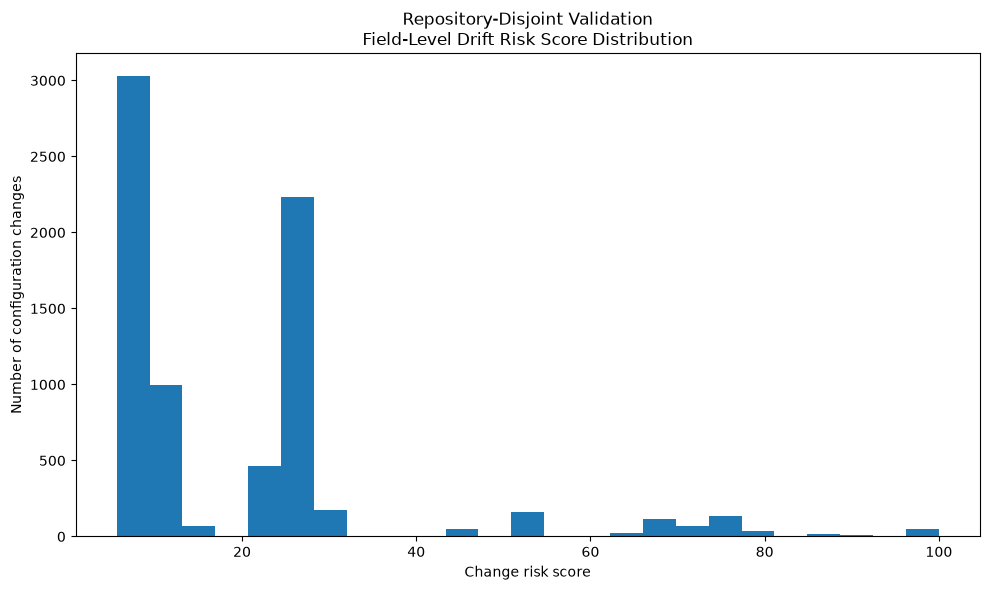

In [24]:
plt.figure(
    figsize=(10, 6)
)

plt.hist(
    hybrid_data[
        "change_risk_score"
    ],
    bins=25,
)

plt.title(
    "Repository-Disjoint Validation\n"
    "Field-Level Drift Risk Score Distribution"
)

plt.xlabel(
    "Change risk score"
)

plt.ylabel(
    "Number of configuration changes"
)

plt.tight_layout()

score_histogram_path = (
    FIGURES_DIR
    / "field_change_score_distribution.png"
)

plt.savefig(
    score_histogram_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

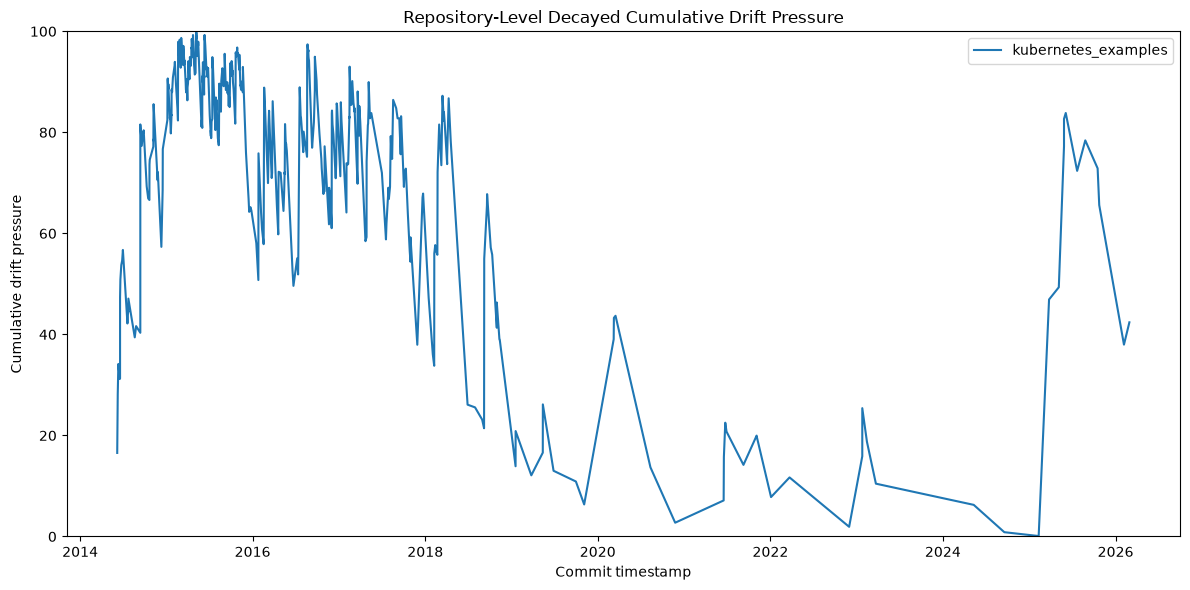

In [25]:
plt.figure(
    figsize=(12, 6)
)

for repository, group in (
    repository_drift_timeline
    .groupby(
        "repository"
    )
):
    ordered_group = group.sort_values(
        "commit_timestamp"
    )

    plt.plot(
        ordered_group[
            "commit_timestamp"
        ],
        ordered_group[
            "cumulative_drift_pressure"
        ],
        label=repository,
    )

plt.title(
    "Repository-Level Decayed Cumulative Drift Pressure"
)

plt.xlabel(
    "Commit timestamp"
)

plt.ylabel(
    "Cumulative drift pressure"
)

plt.ylim(
    0,
    100,
)

plt.legend()

plt.tight_layout()

repository_timeline_figure_path = (
    FIGURES_DIR
    / "repository_drift_pressure_timeline.png"
)

plt.savefig(
    repository_timeline_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [26]:
field_scores_path = (
    PREDICTIONS_DIR
    / "field_level_drift_scores.csv.gz"
)

hybrid_data.to_csv(
    field_scores_path,
    index=False,
    compression="gzip",
)

commit_scores_path = (
    TABLES_DIR
    / "commit_drift_scores.csv.gz"
)

commit_scores.to_csv(
    commit_scores_path,
    index=False,
    compression="gzip",
)

file_timeline_path = (
    TIMELINES_DIR
    / "file_drift_timeline.csv.gz"
)

file_drift_timeline.to_csv(
    file_timeline_path,
    index=False,
    compression="gzip",
)

repository_timeline_path = (
    TIMELINES_DIR
    / "repository_drift_timeline.csv.gz"
)

repository_drift_timeline.to_csv(
    repository_timeline_path,
    index=False,
    compression="gzip",
)

file_snapshot_path = (
    TABLES_DIR
    / "current_file_drift_snapshot.csv"
)

file_current_snapshot.to_csv(
    file_snapshot_path,
    index=False,
)

repository_snapshot_path = (
    TABLES_DIR
    / "current_repository_drift_snapshot.csv"
)

repository_current_snapshot.to_csv(
    repository_snapshot_path,
    index=False,
)

file_hotspots_path = (
    TABLES_DIR
    / "top_file_drift_hotspots.csv"
)

file_hotspots.to_csv(
    file_hotspots_path,
    index=False,
)

commit_hotspots_path = (
    TABLES_DIR
    / "top_commit_drift_hotspots.csv"
)

commit_hotspots.to_csv(
    commit_hotspots_path,
    index=False,
)

field_hotspots_path = (
    TABLES_DIR
    / "top_field_drift_hotspots.csv"
)

field_hotspots.to_csv(
    field_hotspots_path,
    index=False,
)

score_distribution_path = (
    TABLES_DIR
    / "drift_score_distribution.csv"
)

score_distribution.to_csv(
    score_distribution_path,
    index=False,
)

score_by_label_path = (
    TABLES_DIR
    / "drift_score_by_validation_label.csv"
)

score_by_label.to_csv(
    score_by_label_path,
    index=False,
)

score_evaluation_path = (
    TABLES_DIR
    / "drift_score_validation_summary.csv"
)

pd.DataFrame(
    [
        score_evaluation_summary
    ]
).to_csv(
    score_evaluation_path,
    index=False,
)

operational_review_path = (
    REVIEW_DIR
    / "operational_drift_review_queue.csv"
)

operational_review_queue.to_csv(
    operational_review_path,
    index=False,
)

print("Field scores        :", field_scores_path)
print("Commit scores       :", commit_scores_path)
print("File timeline       :", file_timeline_path)
print("Repository timeline :", repository_timeline_path)
print("Review queue        :", operational_review_path)

Field scores        : C:\Users\Lenovo\Desktop\DriftGuard\outputs\drift_scoring\predictions\field_level_drift_scores.csv.gz
Commit scores       : C:\Users\Lenovo\Desktop\DriftGuard\outputs\drift_scoring\tables\commit_drift_scores.csv.gz
File timeline       : C:\Users\Lenovo\Desktop\DriftGuard\outputs\drift_scoring\timelines\file_drift_timeline.csv.gz
Repository timeline : C:\Users\Lenovo\Desktop\DriftGuard\outputs\drift_scoring\timelines\repository_drift_timeline.csv.gz
Review queue        : C:\Users\Lenovo\Desktop\DriftGuard\outputs\drift_scoring\manual_review\operational_drift_review_queue.csv


In [27]:
drift_scoring_manifest = {
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "engine_name":
        "DriftGuard Cumulative Drift Scoring Engine",

    "source_hybrid_manifest":
        str(
            HYBRID_MANIFEST_PATH.relative_to(
                PROJECT_ROOT
            )
        ),

    "scoring_settings":
        DRIFT_SCORING_SETTINGS,

    "validation_records":
        int(
            len(
                hybrid_data
            )
        ),

    "validation_labeled_records":
        int(
            labeled_mask.sum()
        ),

    "validation_evaluation":
        score_evaluation_summary,

    "score_interpretation": {
        "change_risk_score": (
            "Estimated security and operational risk for "
            "one field-level configuration change."
        ),

        "score_confidence": (
            "Evidence confidence based on model confidence, "
            "model agreement, and deterministic-rule support."
        ),

        "uncertainty_score": (
            "Normalized probability entropy. Higher values "
            "indicate less decisive model output."
        ),

        "cumulative_drift_pressure": (
            "A bounded and time-decayed aggregation of recent "
            "drift events. It is not proof that an earlier "
            "configuration issue remains active."
        ),
    },

    "output_files": {
        "field_scores":
            str(
                field_scores_path.relative_to(
                    PROJECT_ROOT
                )
            ),

        "commit_scores":
            str(
                commit_scores_path.relative_to(
                    PROJECT_ROOT
                )
            ),

        "file_timeline":
            str(
                file_timeline_path.relative_to(
                    PROJECT_ROOT
                )
            ),

        "repository_timeline":
            str(
                repository_timeline_path.relative_to(
                    PROJECT_ROOT
                )
            ),

        "repository_snapshot":
            str(
                repository_snapshot_path.relative_to(
                    PROJECT_ROOT
                )
            ),

        "operational_review_queue":
            str(
                operational_review_path.relative_to(
                    PROJECT_ROOT
                )
            ),
    },

    "final_test": {
        "status":
            sealed_test_manifest[
                "status"
            ],

        "sha256":
            sealed_test_manifest[
                "sha256"
            ],

        "file_path":
            sealed_test_manifest[
                "file_path"
            ],
    },

    "next_stage": (
        "Export the frozen models, rule engine, scoring "
        "configuration, and inference API."
    ),
}

drift_scoring_manifest_path = (
    MANIFESTS_DIR
    / "drift_scoring_manifest.json"
)

with drift_scoring_manifest_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        drift_scoring_manifest,
        file,
        indent=2,
    )

print(
    "Scoring manifest:",
    drift_scoring_manifest_path,
)

Scoring manifest: C:\Users\Lenovo\Desktop\DriftGuard\outputs\drift_scoring\manifests\drift_scoring_manifest.json


In [28]:
valid_drift_bands = {
    "stable",
    "watch",
    "concerning",
    "high",
    "critical",
}

drift_integrity_checks = {
    "Scoring dataset is not empty":
        len(
            hybrid_data
        )
        > 0,

    "Scoring row count matches hybrid input":
        len(
            hybrid_data
        )
        == 7628,

    "No forbidden label columns are scoring inputs":
        len(
            scoring_label_overlap
        )
        == 0,

    "Hybrid dataset has unique column names":
        not hybrid_data.columns.duplicated().any(),

    "All change scores are finite":
        np.isfinite(
            hybrid_data[
                "change_risk_score"
            ]
        ).all(),

    "All change scores are between zero and one hundred":
        hybrid_data[
            "change_risk_score"
        ].between(
            0.0,
            100.0,
            inclusive="both",
        ).all(),

    "All score confidence values are valid":
        hybrid_data[
            "score_confidence"
        ].between(
            0.0,
            100.0,
            inclusive="both",
        ).all(),

    "All uncertainty scores are valid":
        hybrid_data[
            "uncertainty_score"
        ].between(
            0.0,
            100.0,
            inclusive="both",
        ).all(),

    "All drift bands are valid":
        set(
            hybrid_data[
                "drift_band"
            ].dropna().unique()
        ).issubset(
            valid_drift_bands
        ),

    "All score-predicted labels are valid":
        hybrid_data[
            "score_predicted_label"
        ].isin(
            CLASS_ORDER
        ).all(),

    "Commit scores are between zero and one hundred":
        commit_scores[
            "commit_drift_score"
        ].between(
            0.0,
            100.0,
            inclusive="both",
        ).all(),

    "File pressure values are valid":
        file_drift_timeline[
            "cumulative_drift_pressure"
        ].between(
            0.0,
            100.0,
            inclusive="both",
        ).all(),

    "Repository pressure values are valid":
        repository_drift_timeline[
            "cumulative_drift_pressure"
        ].between(
            0.0,
            100.0,
            inclusive="both",
        ).all(),

    "Repository snapshot covers every validation repository":
        repository_current_snapshot[
            "repository"
        ].nunique()
        == hybrid_data[
            "repository"
        ].nunique(),

    "Severity anchors are strictly increasing":
        all(
            SEVERITY_ANCHORS[
                CLASS_ORDER[index]
            ]
            < SEVERITY_ANCHORS[
                CLASS_ORDER[
                    index + 1
                ]
            ]
            for index in range(
                len(CLASS_ORDER) - 1
            )
        ),

    "Final test remains sealed":
        sealed_test_manifest[
            "status"
        ]
        == "SEALED_NOT_LOADED",

    "Final test hash is unchanged":
        sealed_test_manifest[
            "sha256"
        ]
        == hybrid_manifest[
            "final_test"
        ][
            "sha256"
        ],

    "Field score output exists":
        field_scores_path.exists(),

    "Commit score output exists":
        commit_scores_path.exists(),

    "File timeline output exists":
        file_timeline_path.exists(),

    "Repository timeline output exists":
        repository_timeline_path.exists(),

    "Operational review queue exists":
        operational_review_path.exists(),

    "Scoring manifest exists":
        drift_scoring_manifest_path.exists(),
}

print("Drift-scoring integrity checks:\n")

for check_name, passed in (
    drift_integrity_checks.items()
):
    print(
        f"{'PASSED' if passed else 'FAILED':<8}"
        f" | {check_name}"
    )

failed_drift_checks = [
    check_name
    for check_name, passed
    in drift_integrity_checks.items()
    if not bool(
        passed
    )
]

print(
    "\nFailed integrity checks:",
    len(
        failed_drift_checks
    ),
)

Drift-scoring integrity checks:

PASSED   | Scoring dataset is not empty
PASSED   | Scoring row count matches hybrid input
PASSED   | No forbidden label columns are scoring inputs
PASSED   | Hybrid dataset has unique column names
PASSED   | All change scores are finite
PASSED   | All change scores are between zero and one hundred
PASSED   | All score confidence values are valid
PASSED   | All uncertainty scores are valid
PASSED   | All drift bands are valid
PASSED   | All score-predicted labels are valid
PASSED   | Commit scores are between zero and one hundred
PASSED   | File pressure values are valid
PASSED   | Repository pressure values are valid
PASSED   | Repository snapshot covers every validation repository
PASSED   | Severity anchors are strictly increasing
PASSED   | Final test remains sealed
PASSED   | Final test hash is unchanged
PASSED   | Field score output exists
PASSED   | Commit score output exists
PASSED   | File timeline output exists
PASSED   | Repository timeline ou

In [30]:
print("=" * 72)
print("NOTEBOOK 12 — REQUIRED RESULTS")
print("=" * 72)

print("\n1. FIELD-LEVEL DRIFT SCORES")
print("-" * 72)

print(
    "Total scored changes:",
    f"{len(hybrid_data):,}",
)

print(
    "Mean change score:",
    f"{hybrid_data['change_risk_score'].mean():.4f}",
)

print(
    "Median change score:",
    f"{hybrid_data['change_risk_score'].median():.4f}",
)

print(
    "Maximum change score:",
    f"{hybrid_data['change_risk_score'].max():.4f}",
)

display(
    score_distribution
)

print("\n2. SCORE CONFIDENCE AND UNCERTAINTY")
print("-" * 72)

print(
    "Mean score confidence:",
    f"{hybrid_data['score_confidence'].mean():.4f}",
)

print(
    "Mean uncertainty score:",
    f"{hybrid_data['uncertainty_score'].mean():.4f}",
)

print(
    "High/critical scored changes:",
    f"{hybrid_data['change_risk_score'].ge(60).sum():,}",
)

print(
    "Critical scored changes:",
    f"{hybrid_data['change_risk_score'].ge(80).sum():,}",
)

print("\n3. COMMIT-LEVEL DRIFT")
print("-" * 72)

print(
    "Scored commits:",
    f"{len(commit_scores):,}",
)

print(
    "Mean commit score:",
    f"{commit_scores['commit_drift_score'].mean():.4f}",
)

print(
    "High/critical commits:",
    f"{commit_scores['commit_drift_score'].ge(60).sum():,}",
)

print(
    "Critical commits:",
    f"{commit_scores['commit_drift_score'].ge(80).sum():,}",
)

display(
    commit_scores[
        [
            "repository",
            "commit_hash",
            "commit_timestamp",
            "changed_fields",
            "changed_files",
            "commit_drift_score",
            "commit_drift_band",
            "critical_change_count",
        ]
    ]
    .sort_values(
        "commit_drift_score",
        ascending=False,
    )
    .head(20)
)

print("\n4. CURRENT REPOSITORY DRIFT SNAPSHOT")
print("-" * 72)

display(
    repository_current_snapshot[
        [
            "repository",
            "commit_timestamp",
            "commit_drift_score",
            "cumulative_drift_pressure",
            "cumulative_drift_band",
            "high_change_count",
            "critical_change_count",
        ]
    ]
)

print("\n5. CURRENT FILE HOTSPOTS")
print("-" * 72)

display(
    file_current_snapshot[
        [
            "repository",
            "file_path",
            "commit_timestamp",
            "file_event_drift_score",
            "cumulative_drift_pressure",
            "cumulative_drift_band",
        ]
    ].head(20)
)

print("\n6. VALIDATION-ONLY SCORE EVALUATION")
print("-" * 72)

for metric_name, metric_value in (
    score_evaluation_summary.items()
):
    if isinstance(
        metric_value,
        float,
    ):
        print(
            f"{metric_name:<32}: "
            f"{metric_value:.6f}"
        )
    else:
        print(
            f"{metric_name:<32}: "
            f"{metric_value}"
        )

print("\n7. OPERATIONAL REVIEW")
print("-" * 72)

print(
    "Review candidates:",
    f"{operational_review_mask.sum():,}",
)

print(
    "Prioritized queue size:",
    f"{len(operational_review_queue):,}",
)

print(
    "Review queue:",
    operational_review_path,
)

print("\n8. OUTPUT ARTIFACTS")
print("-" * 72)

print(
    "Field scores:",
    field_scores_path,
)

print(
    "Commit scores:",
    commit_scores_path,
)

print(
    "File timeline:",
    file_timeline_path,
)

print(
    "Repository timeline:",
    repository_timeline_path,
)

print(
    "Scoring manifest:",
    drift_scoring_manifest_path,
)

print("\n9. SEALED FINAL TEST")
print("-" * 72)

print(
    "Status:",
    sealed_test_manifest[
        "status"
    ],
)

print(
    "SHA-256:",
    sealed_test_manifest[
        "sha256"
    ],
)

print("\n10. FAILED INTEGRITY CHECKS")
print("-" * 72)

if failed_drift_checks:
    for index, check_name in enumerate(
        failed_drift_checks,
        start=1,
    ):
        print(
            f"{index}. {check_name}"
        )
else:
    print(
        "No failed integrity checks."
    )

    print(
        "All drift-scoring integrity checks passed."
    )

print("\n" + "=" * 72)
print("REQUIRED RESULTS GENERATED")
print("=" * 72)

NOTEBOOK 12 — REQUIRED RESULTS

1. FIELD-LEVEL DRIFT SCORES
------------------------------------------------------------------------
Total scored changes: 7,628
Mean change score: 20.0668
Median change score: 11.4506
Maximum change score: 100.0000


,drift_band,records,percentage
0,stable,4079,53.474043
1,watch,2883,37.794966
2,concerning,209,2.739906
3,high,349,4.575249
4,critical,108,1.415836



2. SCORE CONFIDENCE AND UNCERTAINTY
------------------------------------------------------------------------
Mean score confidence: 77.4287
Mean uncertainty score: 43.9127
High/critical scored changes: 457
Critical scored changes: 108

3. COMMIT-LEVEL DRIFT
------------------------------------------------------------------------
Scored commits: 534
Mean commit score: 33.2984
High/critical commits: 100
Critical commits: 34


,repository,commit_hash,commit_timestamp,changed_fields,changed_files,commit_drift_score,commit_drift_band,critical_change_count
525,kubernetes_examples,4eebb8c87a66cdd723bc599c534019aa678e4408,2025-05-27 15:57:32+00:00,74,4,99.889641,critical,6
216,kubernetes_examples,1219478f1b08a44fcc99f0ca4dfd8c808b019382,2015-07-14 16:32:07+00:00,207,43,98.933731,critical,3
341,kubernetes_examples,afb2eff237a46abde1fa4c1278b63980eab26249,2016-07-16 19:08:11+00:00,86,5,96.656415,critical,6
529,kubernetes_examples,289fdef1b9098439909fd22735a886f5e44d8229,2025-08-25 17:17:44+00:00,144,9,96.421481,critical,5
64,kubernetes_examples,07bd1473751daf665b42445f98cbff4341b3c49e,2015-02-19 12:38:22+00:00,41,6,96.287921,critical,3
415,kubernetes_examples,48540305e652ab439fe0a44decaab1eae81eb8fe,2017-03-20 17:53:06+00:00,17,2,94.656630,critical,9
57,kubernetes_examples,6ef691cf3aa2dca002e9c20329b408ec625d22fc,2015-02-04 04:35:13+00:00,49,5,93.576448,critical,2
139,kubernetes_examples,de6b41f95853d7d2f773fde993e6cbccc4e5da4c,2015-05-05 14:23:47+00:00,31,3,93.562985,critical,2
250,kubernetes_examples,e97070d8f1bb83a924ba73d4c94240e1d47c3bf6,2015-09-28 12:03:06+00:00,29,4,92.990024,critical,2
471,kubernetes_examples,e4cc298ab61807a39086ef91374d0b6d87a2a9f4,2018-03-14 18:26:26+00:00,118,31,92.704091,critical,1



4. CURRENT REPOSITORY DRIFT SNAPSHOT
------------------------------------------------------------------------


,repository,commit_timestamp,commit_drift_score,cumulative_drift_pressure,cumulative_drift_band,high_change_count,critical_change_count
0,kubernetes_examples,2026-02-28 09:59:04+00:00,39.730213,42.399045,concerning,0,0



5. CURRENT FILE HOTSPOTS
------------------------------------------------------------------------


,repository,file_path,commit_timestamp,file_event_drift_score,cumulative_drift_pressure,cumulative_drift_band
0,kubernetes_examples,mysql-wordpress-pd/mysql-deployment.yaml,2025-05-27 15:57:32+00:00,98.050930,74.006219,high
1,kubernetes_examples,scheduler/scheduler-policy-config-with-extende...,2018-04-09 21:46:53+00:00,81.306044,66.869046,high
2,kubernetes_examples,monitoring/influx-grafana-pod.json,2015-01-05 18:22:04+00:00,69.144572,65.673298,high
3,kubernetes_examples,mysql-wordpress-pd/v1beta3/wordpress.yaml,2015-05-06 22:14:16+00:00,64.077139,65.649314,high
4,kubernetes_examples,openshift-origin/origin-kubeconfig.yaml,2015-05-05 14:23:47+00:00,84.493139,65.397286,high
5,kubernetes_examples,multi-pod.yaml,2015-07-14 16:32:07+00:00,74.530227,64.725815,high
6,kubernetes_examples,staging/javaweb-tomcat-sidecar/javaweb.yaml,2018-09-19 15:38:42+00:00,21.666752,64.103588,high
7,kubernetes_examples,resourcequota/v1beta3/resource-quota.json,2015-05-07 20:54:24+00:00,83.104127,63.860396,high
8,kubernetes_examples,AI/vllm-deployment/hpa/prometheus-adapter.yaml,2025-08-25 17:17:44+00:00,96.331095,62.350235,high
9,kubernetes_examples,experimental/persistent-volume-provisioning/qu...,2016-09-16 11:25:25+00:00,69.276848,60.580206,high



6. VALIDATION-ONLY SCORE EVALUATION
------------------------------------------------------------------------
labeled_records                 : 7040
accuracy                        : 0.715909
balanced_accuracy               : 0.706629
macro_f1                        : 0.415519
weighted_f1                     : 0.741533
severity_rank_correlation       : 0.500516
mean_absolute_anchor_error      : 9.286160
critical_precision              : 0.120370
critical_recall                 : 0.500000
critical_f1                     : 0.194030
high_critical_precision         : 0.206490
high_critical_recall            : 0.843373
high_critical_f1                : 0.331754

7. OPERATIONAL REVIEW
------------------------------------------------------------------------
Review candidates: 1,170
Prioritized queue size: 1,000
Review queue: C:\Users\Lenovo\Desktop\DriftGuard\outputs\drift_scoring\manual_review\operational_drift_review_queue.csv

8. OUTPUT ARTIFACTS
-------------------------------------------

In [31]:
print("=" * 72)
print("NOTEBOOK 12 COMPLETED")
print("=" * 72)

print(
    "Field changes scored:",
    f"{len(hybrid_data):,}",
)

print(
    "Commits scored:",
    f"{len(commit_scores):,}",
)

print(
    "Files tracked:",
    f"{len(file_current_snapshot):,}",
)

print(
    "Repositories tracked:",
    f"{len(repository_current_snapshot):,}",
)

print(
    "High/critical field changes:",
    f"{hybrid_data['change_risk_score'].ge(60).sum():,}",
)

print(
    "Operational review queue:",
    f"{len(operational_review_queue):,}",
)

print(
    "Scoring manifest:",
    drift_scoring_manifest_path,
)

print(
    "Final test status:",
    sealed_test_manifest[
        "status"
    ],
)

print("\nNext notebook:")
print("13_export_models_and_inference.ipynb")

NOTEBOOK 12 COMPLETED
Field changes scored: 7,628
Commits scored: 534
Files tracked: 609
Repositories tracked: 1
High/critical field changes: 457
Operational review queue: 1,000
Scoring manifest: C:\Users\Lenovo\Desktop\DriftGuard\outputs\drift_scoring\manifests\drift_scoring_manifest.json
Final test status: SEALED_NOT_LOADED

Next notebook:
13_export_models_and_inference.ipynb
